In [42]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib.pyplot as plt

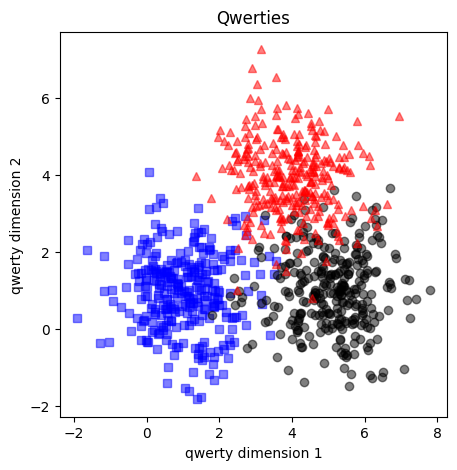

In [43]:
nPerClust = 300
blur = 1

A = [1,1]
B = [5,1]
C = [4,4]

a = [ A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur, C[1]+np.random.randn(nPerClust)*blur ]

labels_np = np.hstack((
    np.zeros((nPerClust)),
    np.ones((nPerClust)),
    1+np.ones((nPerClust))
))

data_np = np.hstack((a, b, c)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0],0], data[np.where(labels==2)[0],1], 'r^', alpha=.5)
plt.title('Qwerties')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [44]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.8)

train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

batchsize = 32
train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [45]:
def createTheQwertyNet(L2lambda):

    class qwertyNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.input = nn.Linear(2,8)

            self.fc1 = nn.Linear(8,8)

            self.output = nn.Linear(8,3)

        def forward(self, x):
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            return self.output(x)

    net = qwertyNet()

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=L2lambda)

    return net, lossfun, optimizer

In [46]:
def function2trainTheModel(L2lambda):

    net, lossfun, optimizer = createTheQwertyNet(L2lambda)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        net.train()

        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append( loss.item() )

            matches = torch.argmax( yHat, axis=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100*torch.mean(matchesNumeric)
            batchAcc.append( accuracyPct )

        trainAcc.append( np.mean(batchAcc) )
        losses[epochi] = np.mean( batchLoss )

        # ===== Test =====
        net.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = net(X)

        testAcc.append( 100*torch.mean((torch.argmax(yHat, axis=1)==y).float()) )

    return trainAcc, testAcc, losses, net

In [47]:
l2lambdas = np.linspace(0,.1,6)

numepochs = 1000

accuracyResultsTrain = np.zeros((numepochs, len(l2lambdas)))
accuracyResultsTest = np.zeros((numepochs, len(l2lambdas)))

for li in range(len(l2lambdas)):

    trainAcc, testAcc, losses, net = function2trainTheModel(l2lambdas[li])

    accuracyResultsTrain[:,li] = trainAcc
    accuracyResultsTest[:,li] = testAcc

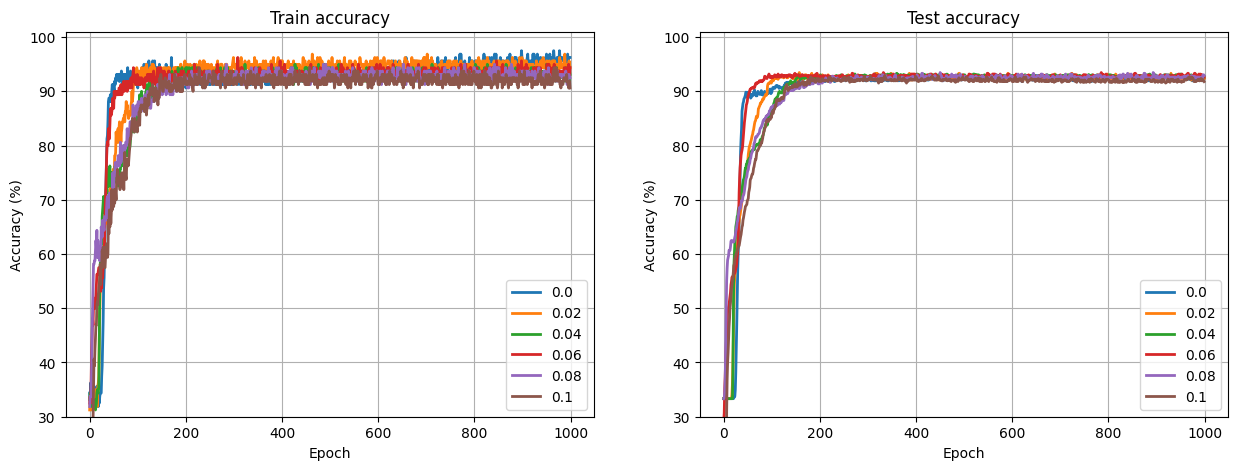

In [48]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(accuracyResultsTrain, linewidth=2)
ax[0].set_title('Train accuracy')
ax[1].plot(accuracyResultsTest, linewidth=2)
ax[1].set_title('Test accuracy')

leglabels = [np.round(i,2) for i in l2lambdas]

for i in range(2):
    ax[i].legend(leglabels)
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy (%)')
    ax[i].set_ylim([30,101])
    ax[i].grid()

plt.show()